# Multi-Modal Human Activity Recognition with Hybrid Deep Learning Models
**CS229 Final Project — Winter 2025–26**
**Team:** Anagha Ramaswamy (`anaghars@stanford.edu`) · Kennesha Garg (`kennesha@stanford.edu`)

---

### Project Overview
We benchmark classical ML baselines against a progression of deep learning architectures — CNN, LSTM, CNN+LSTM, TCN, and TCN with Domain Adaptation (DANN) — on 6-axis IMU sensor data from the KU-HAR dataset.

** Central Question **
Do hybrid architectures that jointly model local spatial patterns and long-range temporal dynamics outperform single-architecture models in the HAR field? We further evaluate cross-dataset generalization to UCI HAR using adversarial domain adaptation.

**Datasets:** KU-HAR (train/val/test) · UCI HAR (cross-dataset transfer target)
**Task:** 6-class activity classification (Walking, Walking Upstairs, Walking Downstairs, Sitting, Standing, Laying)
**Primary metric:** Macro F1-score (accounts for class imbalance)

## 1. Environment Setup

We begin by mounting Google Drive and configuring all source and data paths.
Raw sensor data has been preprocessed into fixed-length windows (128 timesteps,
6 channels) and stored as NumPy arrays. Source files (`config.py`, `models.py`,
`train.py`, `evaluate.py`) are loaded directly from Drive so any updates are
reflected without re-uploading.

In [30]:
from google.colab import drive
import sys, os

drive.mount('/content/drive', force_remount=True)

SRC_PATH  = '/content/drive/MyDrive/kennygarg229/updates/src'
DATA_PATH = '/content/drive/MyDrive/kennygarg229/updates/processed_combined'

assert os.path.isdir(SRC_PATH),  f"src not found:  {SRC_PATH}"
assert os.path.isdir(DATA_PATH), f"data not found: {DATA_PATH}"

if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

print(f"Drive mounted")
print(f"src  → {SRC_PATH}")
print(f"data → {DATA_PATH}")
print("\nProcessed data files:")
for f in sorted(os.listdir(DATA_PATH)):
    size = os.path.getsize(os.path.join(DATA_PATH, f)) / 1e6
    print(f"  {f:45s}  {size:.1f} MB")

Mounted at /content/drive
Drive mounted
src  → /content/drive/MyDrive/kennygarg229/updates/src
data → /content/drive/MyDrive/kennygarg229/updates/processed_combined

Processed data files:
  X_cross_test.npy                               19.4 MB
  X_cross_test_features.npy                      4.4 MB
  X_target_domain.npy                            43.9 MB
  X_test.npy                                     18.4 MB
  X_test_features.npy                            4.2 MB
  X_train.npy                                    83.2 MB
  X_train_features.npy                           19.1 MB
  X_val.npy                                      12.5 MB
  X_val_features.npy                             2.9 MB
  feature_names.json                             0.0 MB
  handoff_info.json                              0.0 MB
  label_map.json                                 0.0 MB
  scaler_stats.json                              0.0 MB
  y_cross_test.npy                               0.0 MB
  y_test.npy          

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
# GPU Verification
import torch
if torch.cuda.is_available():
    gpu  = torch.cuda.get_device_name(0)
    mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU     : {gpu}")
    print(f"  Memory  : {mem:.1f} GB")
    print(f"  PyTorch : {torch.__version__}")
    print(f"  CUDA    : {torch.version.cuda}")
    print("  Status  : Ready to train")
else:
    print("  No GPU detected")

  GPU     : Tesla T4
  Memory  : 15.6 GB
  PyTorch : 2.10.0+cu128
  CUDA    : 12.8
  Status  : Ready to train


In [4]:
# Install dependencies
!pip install -q tqdm scikit-learn scipy matplotlib seaborn xgboost
print("Dependencies installed.")

Dependencies installed.


## 4. Directory Structure

Creating local working directories for source files, data, and results.
All outputs (model checkpoints, figures, metrics) are saved here during training.



In [33]:
import os
dirs = [
    '/content/src',
    '/content/data/processed_combined',
    '/content/results/models',
    '/content/results/figures',
    '/content/results/metrics',
]

for d in dirs:
    os.makedirs(d, exist_ok=True)
    print(f" {d}")

 /content/src
 /content/data/processed_combined
 /content/results/models
 /content/results/figures
 /content/results/metrics


## 5. Data Verification

Verifying all source and data files are present before training.
Each split is validated for shape and dtype to catch any preprocessing issues early.

| Split | Description |
|-------|-------------|
| `X_train / y_train` | KU-HAR training set (subject-stratified) |
| `X_val / y_val` | KU-HAR validation set |
| `X_test / y_test` | KU-HAR held-out test set (within-dataset) |
| `X_cross_test / y_cross_test` | UCI HAR test set (cross-dataset generalization) |
| `X_target_domain` | UCI HAR unlabeled data for DANN domain adaptation |

In [34]:
import sys, os, shutil, json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix

DRIVE_SRC  = '/content/drive/MyDrive/kennygarg229/updates/src'
DRIVE_DATA = '/content/drive/MyDrive/kennygarg229/updates/processed_combined'
LOCAL_SRC  = '/content/src'
LOCAL_DATA = '/content/data/processed_combined'

print("Syncing from Google Drive...")
shutil.copytree(DRIVE_SRC,  LOCAL_SRC,  dirs_exist_ok=True)
shutil.copytree(DRIVE_DATA, LOCAL_DATA, dirs_exist_ok=True)
print(f"  src  → {LOCAL_SRC}")
print(f"  data → {LOCAL_DATA}")

sys.path.insert(0, LOCAL_SRC)

from config import *
from models import create_model, count_parameters
from train  import HARTrainer
from evaluate import ModelEvaluator

COMBINED_PROCESSED_PATH = Path(LOCAL_DATA)
MODELS_PATH  = Path('/content/results/models')
FIGURES_PATH = Path('/content/results/figures')
METRICS_PATH = Path('/content/results/metrics')
for p in [MODELS_PATH, FIGURES_PATH, METRICS_PATH]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
label_names = ['Walking', 'Walk Up', 'Walk Down', 'Sitting', 'Standing', 'Laying']

if 'all_results' not in dir():
    all_results = {}

def get_predictions(trainer, X, y):
    dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(X.transpose(0, 2, 1)),
        torch.LongTensor(y)
    )
    loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)
    trainer.model.eval()
    preds = []
    with torch.no_grad():
        for data, _ in loader:
            data = data.to(trainer.device)
            if trainer.model_name == 'TCN_DA':
                out, _ = trainer.model(data)
            else:
                out = trainer.model(data)
            preds.extend(out.argmax(1).cpu().numpy())
    return np.array(preds)

print(f"\n✓ All imports complete")
print(f"  Device : {DEVICE}")
print(f"  Paths  : results → /content/results/")

Syncing from Google Drive...
  src  → /content/src
  data → /content/data/processed_combined

✓ All imports complete
  Device : cuda
  Paths  : results → /content/results/


In [35]:
import numpy as np
from pathlib import Path

data_dir = Path('/content/data/processed_combined')
src_dir  = Path('/content/src')

all_ok = True

print("=== Source Files ===")
for f in ['config.py', 'models.py', 'train.py', 'evaluate.py']:
    exists = (src_dir / f).exists()
    print(f"  {'ok' if exists else 'missing'} {f}")
    if not exists: all_ok = False

print("\n=== Data Files ===")
for f in [
    'X_train.npy', 'y_train.npy',
    'X_val.npy',   'y_val.npy',
    'X_test.npy',  'y_test.npy',
    'X_cross_test.npy', 'y_cross_test.npy',
    'X_target_domain.npy',
    'label_map.json', 'scaler_stats.json',
]:
    path = data_dir / f
    if path.exists():
        if f.endswith('.npy'):
            d = np.load(path)
            print(f"  {f:35s} shape={str(d.shape):20s} dtype={d.dtype}")
        else:
            print(f"  {f}")
    else:
        print(f"  {f}  is missing")
        all_ok = False

print()
print("All files present" if all_ok else "Missing files.")

=== Source Files ===
  ok config.py
  ok models.py
  ok train.py
  ok evaluate.py

=== Data Files ===
  X_train.npy                         shape=(13548, 128, 6)      dtype=float64
  y_train.npy                         shape=(13548,)             dtype=int64
  X_val.npy                           shape=(2037, 128, 6)       dtype=float64
  y_val.npy                           shape=(2037,)              dtype=int64
  X_test.npy                          shape=(3002, 128, 6)       dtype=float64
  y_test.npy                          shape=(3002,)              dtype=int64
  X_cross_test.npy                    shape=(3155, 128, 6)       dtype=float64
  y_cross_test.npy                    shape=(3155,)              dtype=int64
  X_target_domain.npy                 shape=(7144, 128, 6)       dtype=float64
  label_map.json
  scaler_stats.json

All files present


## 7. Loading Data

We work with two datasets throughout this project:

- **KU-HAR** — primary training dataset collected at 50 Hz from smartphones.
  Originally 18 activity classes; we retain the 6 with clean UCI HAR equivalents,
  dropping 12 KU-HAR-specific activities (Jump, Run, Push-up, Walk-backward, etc.)
  to enable fair cross-dataset evaluation. Split by subject to prevent data leakage.

- **UCI HAR** — held-out cross-dataset evaluation target. Collected under different
  device placement, subject pool, and recording conditions than KU-HAR, making it
  a strict test of generalization. The unlabeled portion (`X_target`) is used
  exclusively by the TCN+DA model for domain alignment — **no labels are seen
  during training**.

In [36]:
X_train  = np.load(data_dir/"X_train.npy")
y_train  = np.load(data_dir/"y_train.npy")
X_val    = np.load(data_dir/"X_val.npy")
y_val    = np.load(data_dir/"y_val.npy")
X_test   = np.load(data_dir/"X_test.npy")
y_test   = np.load(data_dir/"y_test.npy")
X_cross  = np.load(data_dir/"X_cross_test.npy")
y_cross  = np.load(data_dir/"y_cross_test.npy")
X_target = np.load(data_dir/"X_target_domain.npy")

label_names = ['Walking', 'Walking Upstairs', 'Walking Downstairs',
               'Sitting', 'Standing', 'Laying']

print(f"{'Split':<12} {'Shape':<25} {'Description'}")
print("-" * 60)
print(f"{'X_train':<12} {str(X_train.shape):<25} KU-HAR training set")
print(f"{'X_val':<12} {str(X_val.shape):<25} KU-HAR validation set")
print(f"{'X_test':<12} {str(X_test.shape):<25} KU-HAR held-out test")
print(f"{'X_cross':<12} {str(X_cross.shape):<25} UCI HAR cross-dataset test")
print(f"{'X_target':<12} {str(X_target.shape):<25} UCI HAR unlabeled (DA only)")
print(f"\nWindow size : {X_train.shape[1]} timesteps @ 50 Hz = 2.56s")
print(f"Channels    : {X_train.shape[2]} (3-axis accel + 3-axis gyro)")
print(f"Classes     : {len(label_names)}")
print("\nAll splits loaded.")

Split        Shape                     Description
------------------------------------------------------------
X_train      (13548, 128, 6)           KU-HAR training set
X_val        (2037, 128, 6)            KU-HAR validation set
X_test       (3002, 128, 6)            KU-HAR held-out test
X_cross      (3155, 128, 6)            UCI HAR cross-dataset test
X_target     (7144, 128, 6)            UCI HAR unlabeled (DA only)

Window size : 128 timesteps @ 50 Hz = 2.56s
Channels    : 6 (3-axis accel + 3-axis gyro)
Classes     : 6

All splits loaded.


## 8. Data Exploration & Analysis

Before modeling, we explore the structure of our sensor data to understand class
distribution, signal characteristics, and feature separability. This motivates
our architectural choices and helps interpret model errors later.

**Dataset construction:** KU-HAR originally contains 18 activity classes collected
at 50 Hz. We retain only the 6 activities with clean equivalents in UCI HAR
(Walking, Walking Upstairs, Walking Downstairs, Sitting, Standing, Laying),
dropping 12 KU-HAR-specific activities (Jump, Run, Push-up, etc.) to enable
meaningful cross-dataset evaluation. Raw 6-axis signals (3-axis accelerometer +
3-axis gyroscope) are segmented into 128-timestep windows (~2.56s) with 50%
overlap and z-score normalized per channel using training set statistics.

Each window is represented two ways:
- **Raw time series** (128 × 6) — input to all deep learning models
- **Hand-crafted feature vector** (176-dim) — input to classical ML baselines,
  comprising 96 time-domain, 48 frequency-domain, and 32 statistical features

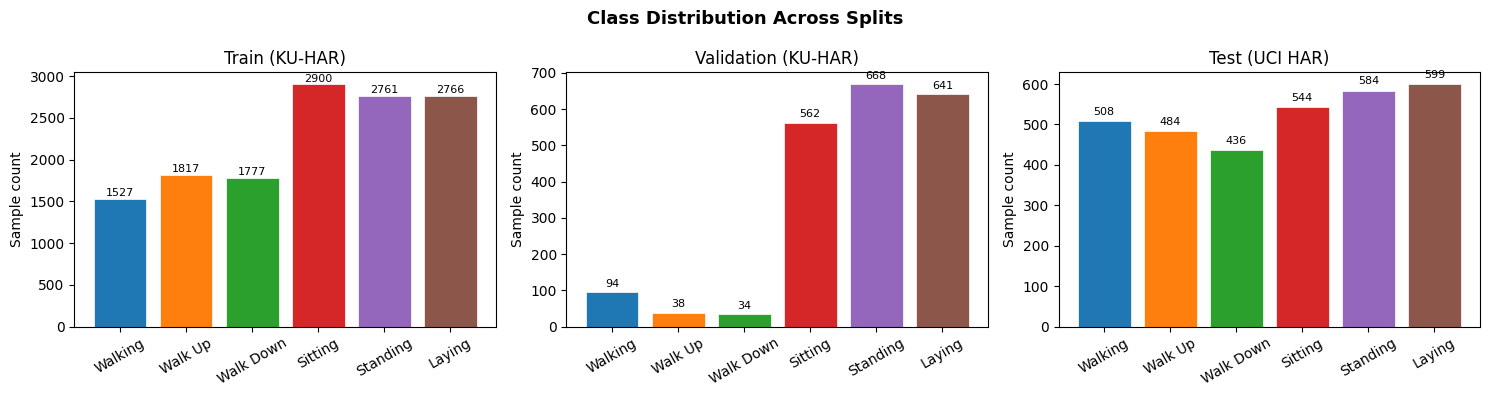

Class imbalance ratio (train):
  Walking             1527  (11.3%)
  Walk Up             1817  (13.4%)
  Walk Down           1777  (13.1%)
  Sitting             2900  (21.4%)
  Standing            2761  (20.4%)
  Laying              2766  (20.4%)


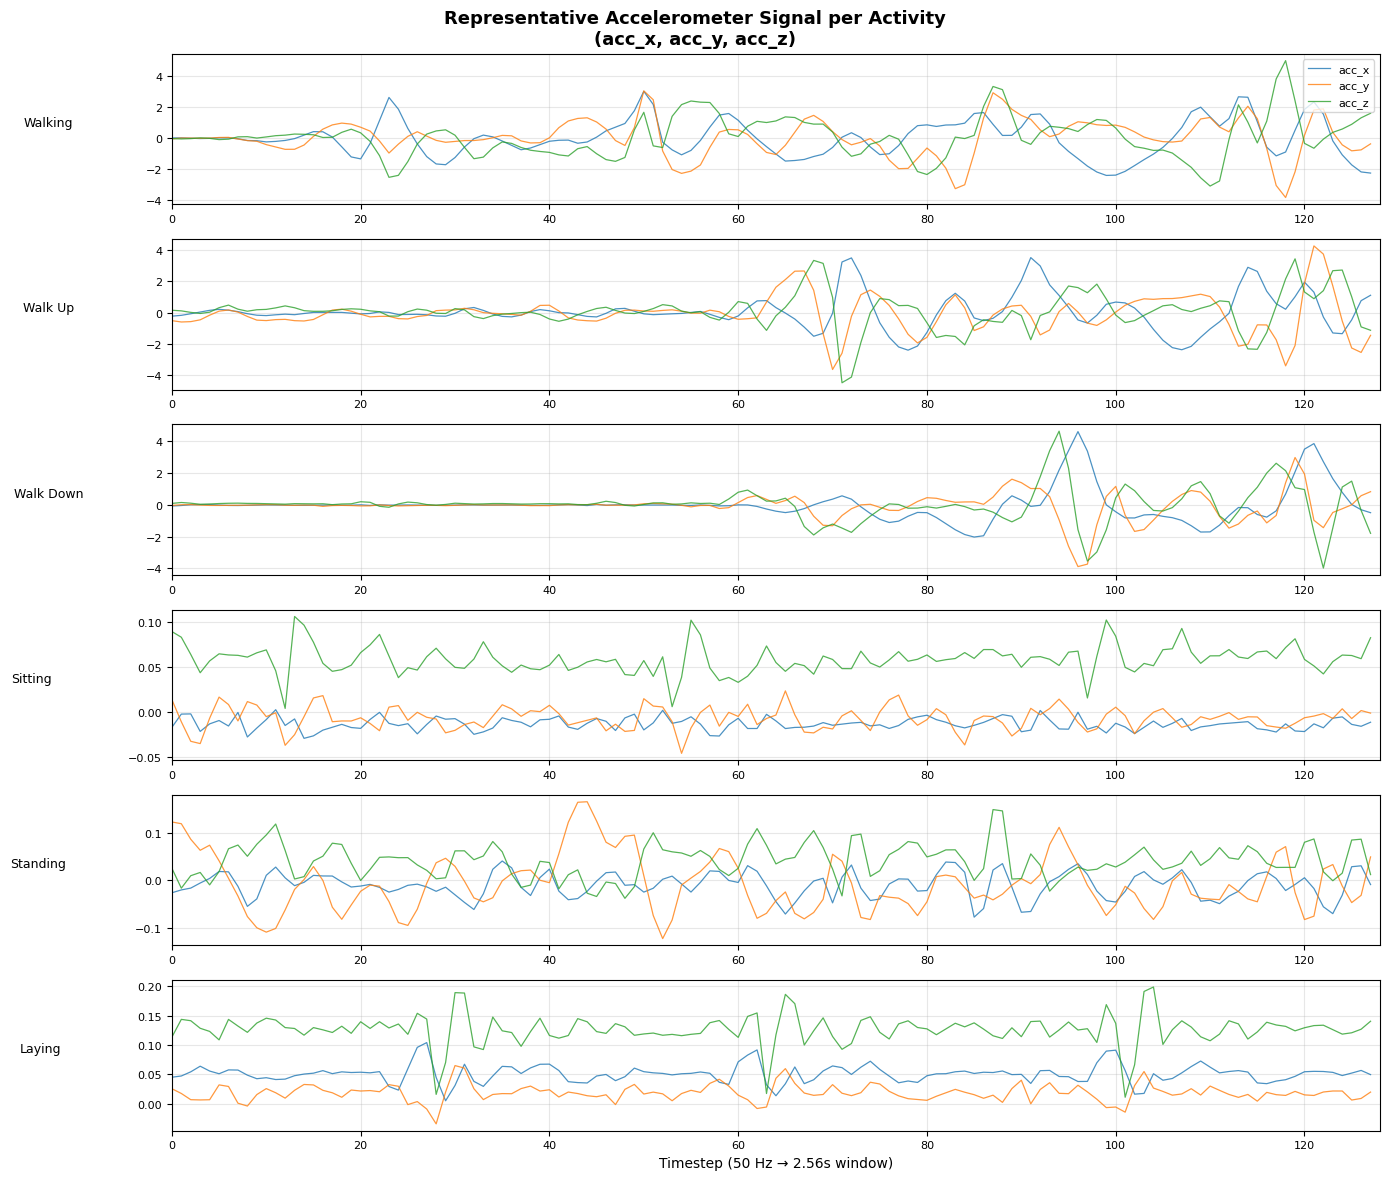


Running PCA on hand-crafted feature vectors...
  Components to explain 90% variance: 31
  PC1 + PC2 explains: 56.3% of variance


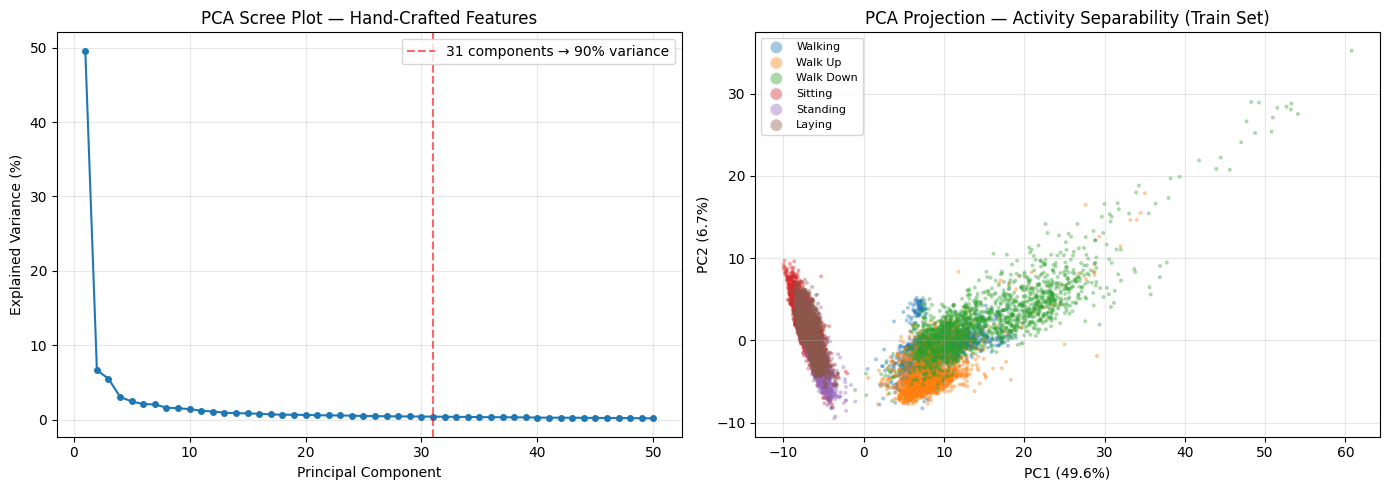

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import json

label_names  = ['Walking', 'Walk Up', 'Walk Down', 'Sitting', 'Standing', 'Laying']
label_colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Class Distribution Across Splits', fontsize=13, fontweight='bold')

for ax, (y, title) in zip(axes, [
    (y_train, 'Train (KU-HAR)'),
    (y_val,   'Validation (KU-HAR)'),
    (y_cross, 'Test (UCI HAR)')
]):
    counts = [np.sum(y == i) for i in range(6)]
    bars = ax.bar(label_names, counts, color=label_colors, edgecolor='white', linewidth=0.5)
    ax.set_title(title)
    ax.set_ylabel('Sample count')
    ax.tick_params(axis='x', rotation=30)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(count), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/content/results/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Class imbalance ratio (train):")
counts = np.bincount(y_train)
for i, (name, c) in enumerate(zip(label_names, counts)):
    print(f"  {name:<18} {c:>5}  ({c/len(y_train)*100:.1f}%)")

fig, axes = plt.subplots(6, 1, figsize=(14, 12))
fig.suptitle('Representative Accelerometer Signal per Activity\n(acc_x, acc_y, acc_z)',
             fontsize=13, fontweight='bold')

channel_labels = ['acc_x', 'acc_y', 'acc_z']
for i in range(6):
    idx = np.where(y_train == i)[0][0]
    window = X_train[idx]
    ax = axes[i]
    for c in range(3):
        ax.plot(window[:, c], color=label_colors[c], alpha=0.8,
                linewidth=0.9, label=channel_labels[c])
    ax.set_ylabel(label_names[i], fontsize=9, rotation=0, labelpad=70)
    ax.set_xlim(0, 128)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Timestep (50 Hz → 2.56s window)')
plt.tight_layout()
plt.savefig('/content/results/figures/sample_signals.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRunning PCA on hand-crafted feature vectors...")
X_train_feat = np.load(data_dir / "X_train_features.npy")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_feat)

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

explained = np.cumsum(pca.explained_variance_ratio_)
n_90 = np.argmax(explained >= 0.90) + 1
print(f"  Components to explain 90% variance: {n_90}")
print(f"  PC1 + PC2 explains: {explained[1]*100:.1f}% of variance")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 51), pca.explained_variance_ratio_ * 100,
             'o-', markersize=4, color='#1f77b4')
axes[0].axvline(n_90, color='red', linestyle='--', alpha=0.6,
                label=f'{n_90} components → 90% variance')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('PCA Scree Plot — Hand-Crafted Features')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
ax = axes[1]
for i in range(6):
    mask = y_train == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=label_colors[i], label=label_names[i],
               alpha=0.4, s=8, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA Projection — Activity Separability (Train Set)')
ax.legend(markerscale=3, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/results/figures/pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### PCA Findings

PC1 (49.6% of variance)  captures signal energy and separates
dynamic activities (walking, stair climbing) from static ones (sitting, standing,
laying). However, the three static activities overlap almost completely and hand-crafted features alone cannot distinguish between them. This is our key motivation for temporal deep learning models, which can exploit *how* the signal evolves over time rather than just *what* it looks like on average.
Dynamic activities also overlap significantly along PC2, particularly Walking Upstairs vs. Downstairs, suggesting these classes require sequential pattern recognition beyond what aggregate statistics capture.
Finally, 31 of 176 features account for 90% of variance, indicating considerable redundancy in the hand-crafted feature space. Deep models can learn more compact, discriminative representations directly from raw signals.

## Deep Learning Models

We train five deep learning architectures in order of increasing complexity.
All models receive raw windows of shape (128, 6) and are evaluated on both
KU-HAR (within-dataset) and UCI HAR (cross-dataset transfer).

Setup:
- Optimizer: Adam (weight decay 1e-4)
- Loss: Cross-entropy (no label smoothing, no class weighting)
- Scheduler: ReduceLROnPlateau (factor=0.5, patience=5) on validation loss
- Early stopping: patience=15 epochs (TCN+DA: 50-epoch warmup before early stopping activates)
- Batch size: 64, max 100 epochs


### CNN

Three 1D convolutional blocks (32→64→128 filters, kernel size 5, stride 1)
each followed by BatchNorm, ReLU, and MaxPool(stride=2), reducing the
128-timestep sequence to 16 temporal positions. The flattened representation
(128×16=2048) passes through two FC layers (256→128, dropout p=0.4) before
the softmax output. All 6 sensor channels are treated as parallel input
streams — filters learn jointly over the full multi-modal signal. Strong at
capturing local waveform shape but has no mechanism to model how patterns
evolve sequentially across the full window.

In [10]:
import json
from pathlib import Path

if 'all_results' not in dir():
    all_results = {}

print("*" * 45)
print("Training CNN")
print("*" * 45)

trainer_cnn = HARTrainer('CNN', device=DEVICE)
trainer_cnn.setup_model()
cnn_val_metrics, cnn_test_metrics, cnn_cross_results = trainer_cnn.train(
    X_train, y_train, X_val, y_val,
    X_test=X_test, y_test=y_test,
    X_cross_test=X_cross, y_cross_test=y_cross
)

cross = cnn_cross_results.get('test', {})

all_results['CNN'] = {
    'val':   cnn_val_metrics,
    'test':  cnn_test_metrics,
    'cross': cross,
}
with open(src_dir / 'all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"\nCNN Results:")
print(f"  KU-HAR Val  Acc: {cnn_val_metrics['accuracy']:.4f}   F1: {cnn_val_metrics['f1_macro']:.4f}")
print(f"  KU-HAR Test Acc: {cnn_test_metrics.get('accuracy', 0):.4f}   F1: {cnn_test_metrics.get('f1_macro', 0):.4f}")
print(f"  UCI Cross   Acc: {cross.get('accuracy', 0):.4f}   F1: {cross.get('f1_macro', 0):.4f}")
print(f"\n✓ Results saved to {src_dir / 'all_results.json'}")

*********************************************
Training CNN
*********************************************
Setting up CNN model...
Model: CNN
Parameters: 611,046
Device: cuda
Training CNN...
Preparing data loaders...


Epoch 1: 100%|██████████| 211/211 [00:05<00:00, 38.73it/s, Loss=0.8623, Acc=49.3%]


Epoch 1/100:
  Train Loss: 0.9442, Train Acc: 49.30%
  Val Loss: 1.1056, Val Acc: 42.37%
  New best model saved! Val Acc: 42.37%


Epoch 2: 100%|██████████| 211/211 [00:03<00:00, 62.98it/s, Loss=0.6743, Acc=61.0%]


Epoch 2/100:
  Train Loss: 0.7021, Train Acc: 61.02%
  Val Loss: 1.0012, Val Acc: 43.94%
  New best model saved! Val Acc: 43.94%


...

Epoch 85/100:
  Train Loss: 0.0723, Train Acc: 97.59%
  Val Loss: 0.6245, Val Acc: 86.55%
  No improvement for 13 epochs


Epoch 86: 100%|██████████| 211/211 [00:02<00:00, 94.17it/s, Loss=0.0187, Acc=97.7%]


Epoch 86/100:
  Train Loss: 0.0750, Train Acc: 97.67%
  Val Loss: 0.5962, Val Acc: 85.86%
  No improvement for 14 epochs


Epoch 87: 100%|██████████| 211/211 [00:02<00:00, 88.93it/s, Loss=0.0416, Acc=97.7%] 


Epoch 87/100:
  Train Loss: 0.0739, Train Acc: 97.66%
  Val Loss: 0.5639, Val Acc: 88.27%
Early stopping triggered after 87 epochs

Final evaluation on validation set:
Validation Accuracy: 88.27%
Validation F1 (macro): 0.8969

Final evaluation on KU-HAR held-out test set:
Test Accuracy: 91.01%
Test F1 (macro): 0.9219

Cross-dataset evaluation (UCI HAR):
test Accuracy: 40.44%
test F1 (macro): 0.3003

CNN Results:
  KU-HAR Val  Acc: 0.8827   F1: 0.8969
  KU-HAR Test Acc: 0.9101   F1: 0.9219
  UCI Cross   Acc: 0.4044   F1: 0.3003

✓ Results saved to /content/src/all_results.json


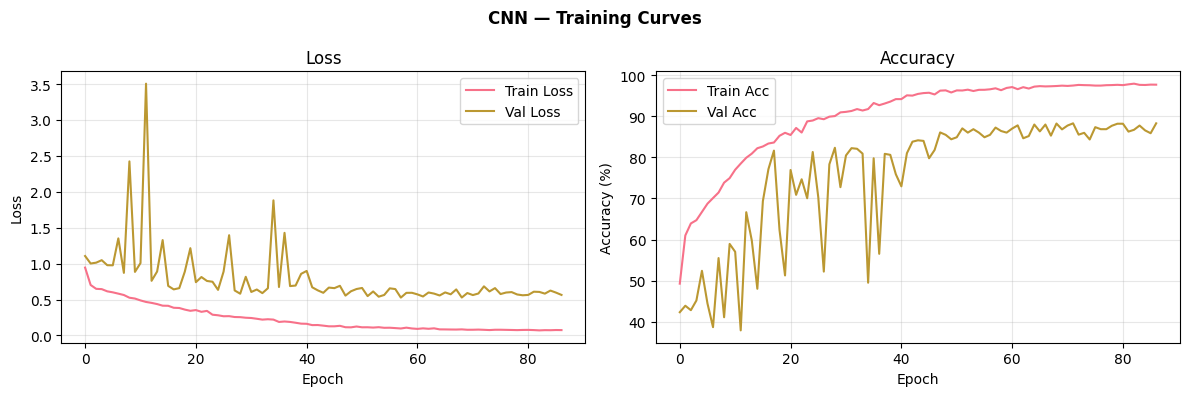

In [11]:
import matplotlib.pyplot as plt

history = trainer_cnn.training_history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('CNN — Training Curves', fontweight='bold')

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'],   label='Val Acc')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/results/figures/cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

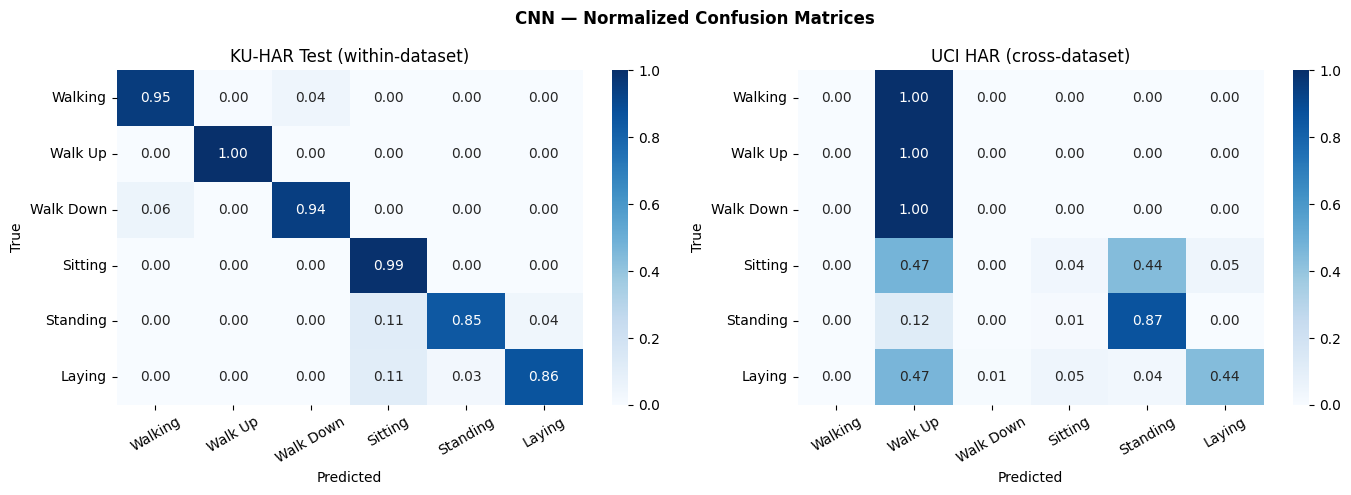

Per-class F1 (KU-HAR): ['0.969', '0.989', '0.877', '0.892', '0.903', '0.902']
Per-class F1 (UCI):    ['0.004', '0.384', '0.000', '0.070', '0.749', '0.595']


In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def get_predictions(trainer, X, y):
    dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(X.transpose(0, 2, 1)),
        torch.LongTensor(y)
    )
    loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)
    trainer.model.eval()
    preds = []
    with torch.no_grad():
        for data, _ in loader:
            data = data.to(trainer.device)
            if trainer.model_name == 'TCN_DA':
                out, _ = trainer.model(data)
            else:
                out = trainer.model(data)
            preds.extend(out.argmax(1).cpu().numpy())
    return np.array(preds)

cnn_test_preds  = get_predictions(trainer_cnn, X_test,  y_test)
cnn_cross_preds = get_predictions(trainer_cnn, X_cross, y_cross)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN — Normalized Confusion Matrices', fontweight='bold')

for ax, (y_true, y_pred, title) in zip(axes, [
    (y_test,  cnn_test_preds,  'KU-HAR Test (within-dataset)'),
    (y_cross, cnn_cross_preds, 'UCI HAR (cross-dataset)'),
]):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names,
                vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('/content/results/figures/cnn_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Store predictions for later cross-model analysis
all_results['CNN']['test_preds']  = cnn_test_preds.tolist()
all_results['CNN']['cross_preds'] = cnn_cross_preds.tolist()
with open(src_dir / 'all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"Per-class F1 (KU-HAR): {[f'{v:.3f}' for v in all_results['CNN']['test']['f1_per_class']]}")
print(f"Per-class F1 (UCI):    {[f'{v:.3f}' for v in all_results['CNN']['cross']['f1_per_class']]}")

The CNN achieves strong within-dataset performance (Test F1: 0.922, Test Acc: 91.0%) but drops sharply on cross-dataset transfer (UCI F1: 0.300, Acc: 40.4%). Per-class F1 on KU-HAR is consistently high across all six activities (0.877–0.989), with Walk Down as the weakest class. On UCI HAR, the model partially preserves static activity structure — Standing (0.749) and Laying (0.595) survive reasonably — but completely fails on Walking (0.004) and Walk Down (0.000), and struggles on Sitting (0.070). This confirms that local convolutional filters latch onto device-placement-specific waveform shapes for dynamic activities that do not transfer across datasets.


### LSTM

A two-layer bidirectional LSTM with 128 hidden units per direction (256-dim
concatenated hidden state). Applied directly to the raw 6-dimensional sensor
sequence (128 timesteps × 6 channels), with dropout p=0.5 between LSTM
layers. The final hidden states from the top layer are concatenated across
both directions and passed through dropout (p=0.5) into a single linear
classifier (256→6). Unlike the CNN, the LSTM has an explicit inductive bias
toward sequential ordering and can track how the signal evolves across the
full window. The bidirectional design integrates both past and future context
at each timestep. However, operating directly on raw signals means it must
learn local feature detection and temporal modeling simultaneously, without
a dedicated feature extraction front-end.


In [13]:
#LSTM
print("*" * 45)
print("Training LSTM")
print("*" * 45)

trainer_lstm = HARTrainer('LSTM', device=DEVICE)
trainer_lstm.setup_model()
lstm_val_metrics, lstm_test_metrics, lstm_cross_results = trainer_lstm.train(
    X_train, y_train, X_val, y_val,
    X_test=X_test, y_test=y_test,
    X_cross_test=X_cross, y_cross_test=y_cross
)

cross = lstm_cross_results.get('test', {})

all_results['LSTM'] = {
    'val':   lstm_val_metrics,
    'test':  lstm_test_metrics,
    'cross': cross,
}
with open(src_dir / 'all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"\nLSTM Results:")
print(f"  KU-HAR Val  Acc: {lstm_val_metrics['accuracy']:.4f}   F1: {lstm_val_metrics['f1_macro']:.4f}")
print(f"  KU-HAR Test Acc: {lstm_test_metrics.get('accuracy', 0):.4f}   F1: {lstm_test_metrics.get('f1_macro', 0):.4f}")
print(f"  UCI Cross   Acc: {cross.get('accuracy', 0):.4f}   F1: {cross.get('f1_macro', 0):.4f}")
print(f"\n✓ Results saved to {src_dir / 'all_results.json'}")

*********************************************
Training LSTM
*********************************************
Setting up LSTM model...
Model: LSTM
Parameters: 536,070
Device: cuda
Training LSTM...
Preparing data loaders...


Epoch 1: 100%|██████████| 211/211 [00:04<00:00, 47.99it/s, Loss=0.9472, Acc=35.1%]


Epoch 1/100:
  Train Loss: 1.2127, Train Acc: 35.11%
  Val Loss: 1.0840, Val Acc: 37.31%
  New best model saved! Val Acc: 37.31%


Epoch 2: 100%|██████████| 211/211 [00:04<00:00, 49.26it/s, Loss=0.7802, Acc=50.8%]


Epoch 2/100:
  Train Loss: 0.8998, Train Acc: 50.78%
  Val Loss: 1.1106, Val Acc: 35.98%
  No improvement for 1 epochs


...

Epoch 17/100:
  Train Loss: 0.6911, Train Acc: 59.06%
  Val Loss: 1.1539, Val Acc: 38.00%
  No improvement for 13 epochs


Epoch 18: 100%|██████████| 211/211 [00:05<00:00, 37.84it/s, Loss=0.5947, Acc=58.7%]


Epoch 18/100:
  Train Loss: 0.6906, Train Acc: 58.67%
  Val Loss: 1.1661, Val Acc: 38.34%
  No improvement for 14 epochs


Epoch 19: 100%|██████████| 211/211 [00:05<00:00, 39.44it/s, Loss=0.5952, Acc=58.9%]


Epoch 19/100:
  Train Loss: 0.6916, Train Acc: 58.88%
  Val Loss: 1.1251, Val Acc: 38.93%
Early stopping triggered after 19 epochs

Final evaluation on validation set:
Validation Accuracy: 48.06%
Validation F1 (macro): 0.5220

Final evaluation on KU-HAR held-out test set:
Test Accuracy: 53.50%
Test F1 (macro): 0.5763

Cross-dataset evaluation (UCI HAR):
test Accuracy: 40.13%
test F1 (macro): 0.2934

LSTM Results:
  KU-HAR Val  Acc: 0.4806   F1: 0.5220
  KU-HAR Test Acc: 0.5350   F1: 0.5763
  UCI Cross   Acc: 0.4013   F1: 0.2934

✓ Results saved to /content/src/all_results.json


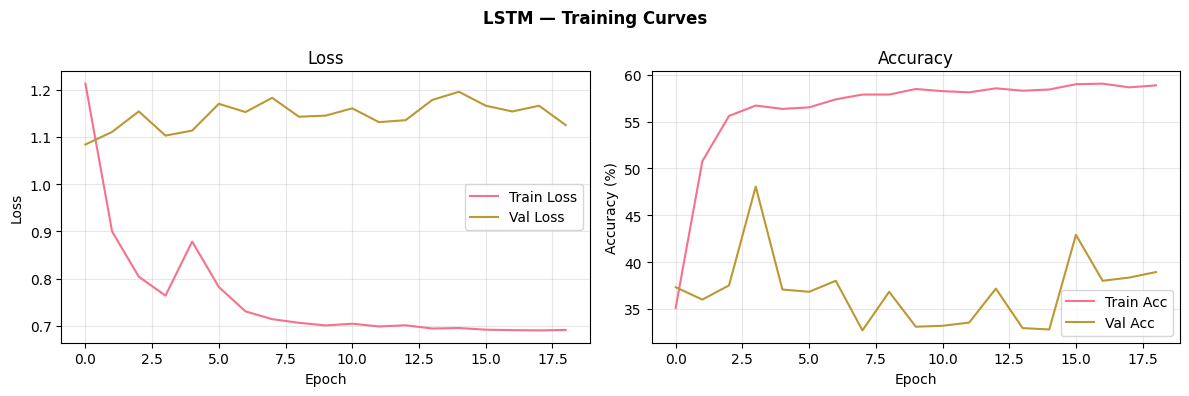

In [14]:
history = trainer_lstm.training_history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('LSTM — Training Curves', fontweight='bold')

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'],   label='Val Acc')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/results/figures/lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

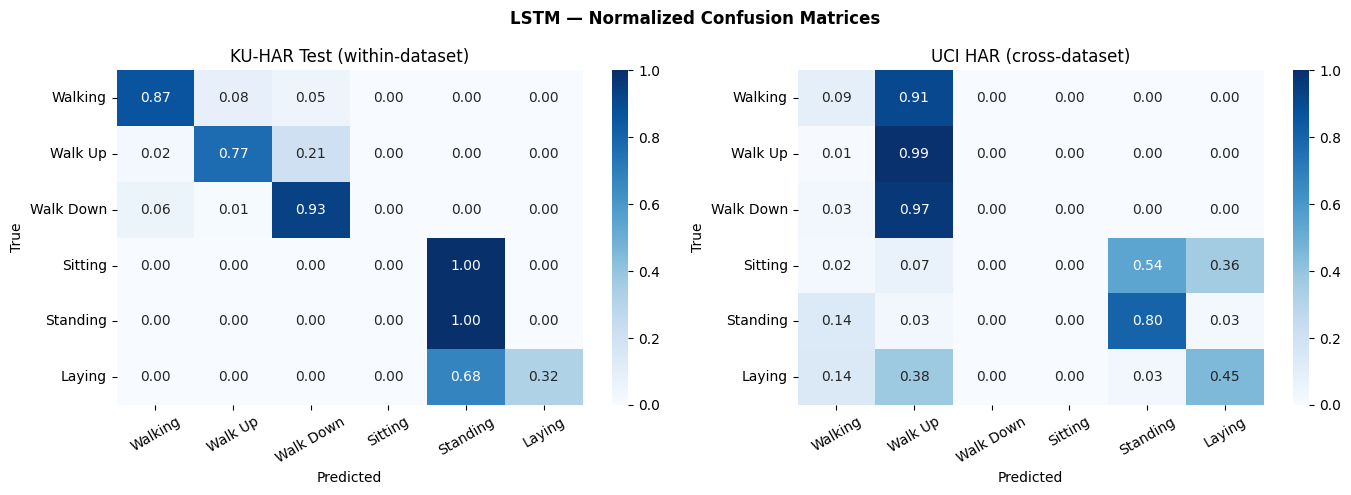

Per-class F1 (KU-HAR): ['0.920', '0.711', '0.779', '0.000', '0.566', '0.483']
Per-class F1 (UCI):    ['0.123', '0.451', '0.000', '0.000', '0.686', '0.501']


In [15]:
lstm_test_preds  = get_predictions(trainer_lstm, X_test,  y_test)
lstm_cross_preds = get_predictions(trainer_lstm, X_cross, y_cross)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM — Normalized Confusion Matrices', fontweight='bold')

for ax, (y_true, y_pred, title) in zip(axes, [
    (y_test,  lstm_test_preds,  'KU-HAR Test (within-dataset)'),
    (y_cross, lstm_cross_preds, 'UCI HAR (cross-dataset)'),
]):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names,
                vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('/content/results/figures/lstm_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
all_results['LSTM']['test_preds']  = lstm_test_preds.tolist()
all_results['LSTM']['cross_preds'] = lstm_cross_preds.tolist()
with open(src_dir / 'all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"Per-class F1 (KU-HAR): {[f'{v:.3f}' for v in all_results['LSTM']['test']['f1_per_class']]}")
print(f"Per-class F1 (UCI):    {[f'{v:.3f}' for v in all_results['LSTM']['cross']['f1_per_class']]}")

The LSTM converges poorly, with validation accuracy plateauing around 48% and early stopping triggered at epoch 19 — indicating the model stalled rather than genuinely learning temporal structure. Within-dataset performance is substantially weaker than the CNN (Test F1: 0.576, Acc: 53.5%), with a striking per-class failure on Sitting (0.000) and weak results on Laying (0.483) and Standing (0.566). The bidirectional LSTM struggles to distinguish static postures from raw sensor sequences alone. Cross-dataset transfer (UCI F1: 0.293, Acc: 40.1%) is slightly better than the CNN in aggregate, but shows complete failure on Walk Down (0.000) and Sitting (0.000) while Standing surprisingly transfers well (0.686).



###CNN+LSTM Hybrid

Our primary hybrid model. The CNN front-end (identical to the CNN-only model
but without the final classification head) processes the raw 128-timestep
window and produces a sequence of 16 high-level local feature vectors
(128-dim each) after three max-pool operations. This compressed sequence is
fed into a two-layer unidirectional LSTM (256 hidden units, dropout p=0.5
between layers), which models temporal ordering and dynamics over
CNN-extracted features rather than raw sensor noise. The final hidden state
passes through a three-layer FC head (256→256→128→6, dropout p=0.5 at each
layer) before the softmax output. This design reflects a principled
decomposition: the CNN handles what local patterns are present, the LSTM
handles how those patterns unfold over time. This is  motivated directly by the
PCA finding that static activities require temporal context.

In [16]:
#  Train CNN+LSTM
print("*" * 45)
print("Training CNN+LSTM")
print("*" * 45)

trainer_cnn_lstm = HARTrainer('CNN_LSTM', device=DEVICE)
trainer_cnn_lstm.setup_model()
cnn_lstm_val_metrics, cnn_lstm_test_metrics, cnn_lstm_cross_results = trainer_cnn_lstm.train(
    X_train, y_train, X_val, y_val,
    X_test=X_test, y_test=y_test,
    X_cross_test=X_cross, y_cross_test=y_cross
)

cross = cnn_lstm_cross_results.get('test', {})

all_results['CNN_LSTM'] = {
    'val':   cnn_lstm_val_metrics,
    'test':  cnn_lstm_test_metrics,
    'cross': cross,
}
with open(src_dir / 'all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"\nCNN+LSTM Results:")
print(f"  KU-HAR Val  Acc: {cnn_lstm_val_metrics['accuracy']:.4f}   F1: {cnn_lstm_val_metrics['f1_macro']:.4f}")
print(f"  KU-HAR Test Acc: {cnn_lstm_test_metrics.get('accuracy', 0):.4f}   F1: {cnn_lstm_test_metrics.get('f1_macro', 0):.4f}")
print(f"  UCI Cross   Acc: {cross.get('accuracy', 0):.4f}   F1: {cross.get('f1_macro', 0):.4f}")
print(f"\n✓ Results saved to {src_dir / 'all_results.json'}")

*********************************************
Training CNN+LSTM
*********************************************
Setting up CNN_LSTM model...
Model: CNN_LSTM
Parameters: 1,073,894
Device: cuda
Training CNN_LSTM...
Preparing data loaders...


Epoch 1: 100%|██████████| 211/211 [00:02<00:00, 70.51it/s, Loss=1.0788, Acc=39.3%]


Epoch 1/100:
  Train Loss: 1.0913, Train Acc: 39.33%
  Val Loss: 1.0789, Val Acc: 33.58%
  New best model saved! Val Acc: 33.58%


Epoch 2: 100%|██████████| 211/211 [00:02<00:00, 88.30it/s, Loss=0.8898, Acc=45.2%] 


Epoch 2/100:
  Train Loss: 0.9230, Train Acc: 45.18%
  Val Loss: 1.0704, Val Acc: 31.08%
  No improvement for 1 epochs


...

Epoch 42/100:
  Train Loss: 0.5526, Train Acc: 70.83%
  Val Loss: 0.7909, Val Acc: 58.37%
  No improvement for 13 epochs


Epoch 43: 100%|██████████| 211/211 [00:02<00:00, 91.01it/s, Loss=0.5253, Acc=70.9%]


Epoch 43/100:
  Train Loss: 0.5560, Train Acc: 70.90%
  Val Loss: 0.7825, Val Acc: 59.35%
  No improvement for 14 epochs


Epoch 44: 100%|██████████| 211/211 [00:02<00:00, 93.33it/s, Loss=0.5576, Acc=71.1%]


Epoch 44/100:
  Train Loss: 0.5486, Train Acc: 71.09%
  Val Loss: 0.8144, Val Acc: 57.04%
Early stopping triggered after 44 epochs

Final evaluation on validation set:
Validation Accuracy: 59.55%
Validation F1 (macro): 0.7311

Final evaluation on KU-HAR held-out test set:
Test Accuracy: 54.26%
Test F1 (macro): 0.6819

Cross-dataset evaluation (UCI HAR):
test Accuracy: 44.85%
test F1 (macro): 0.3506

CNN+LSTM Results:
  KU-HAR Val  Acc: 0.5955   F1: 0.7311
  KU-HAR Test Acc: 0.5426   F1: 0.6819
  UCI Cross   Acc: 0.4485   F1: 0.3506

✓ Results saved to /content/src/all_results.json


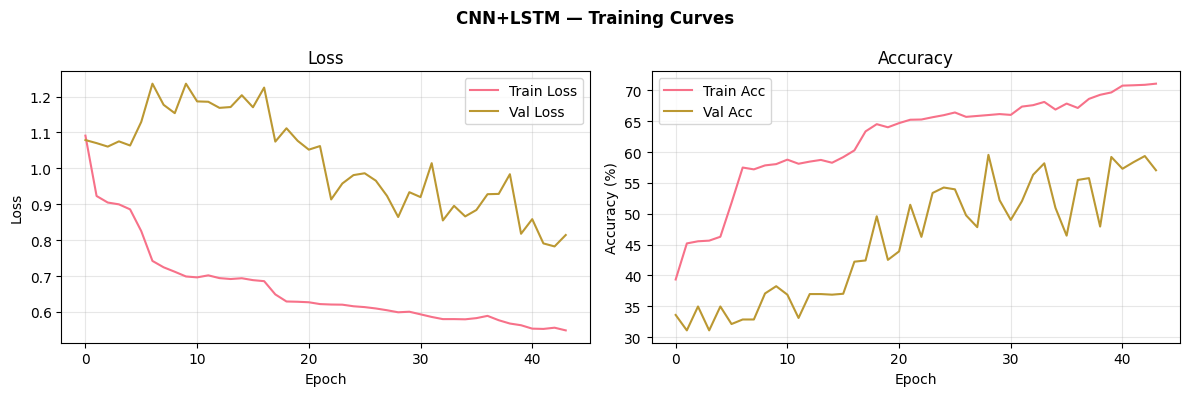

In [17]:
history = trainer_cnn_lstm.training_history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('CNN+LSTM — Training Curves', fontweight='bold')
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'],   label='Val Acc')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/results/figures/cnn_lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

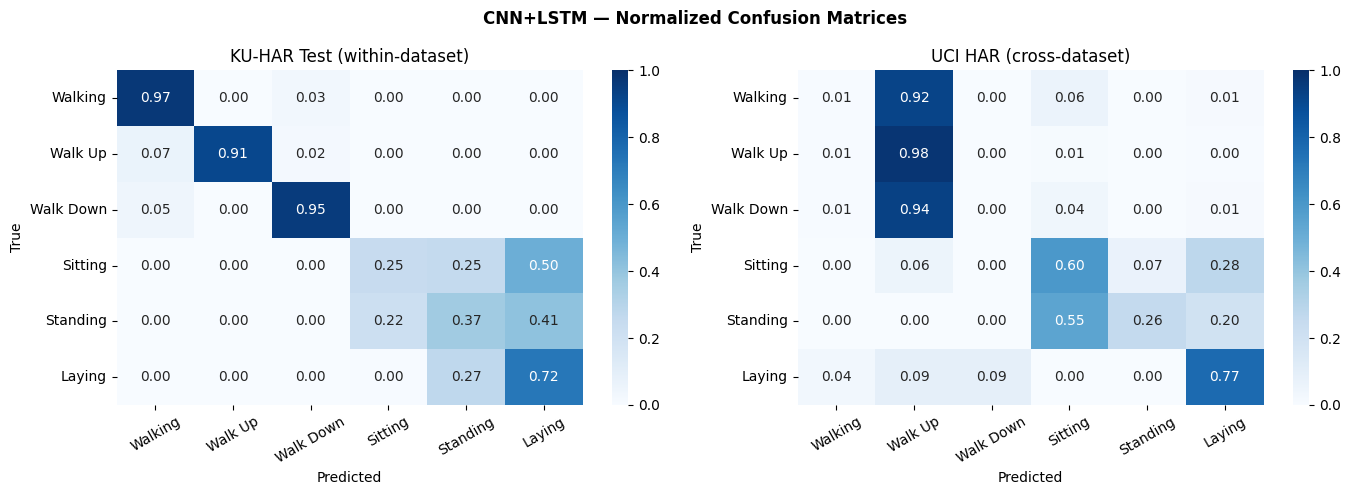

Per-class F1 (KU-HAR): ['0.972', '0.954', '0.897', '0.334', '0.398', '0.536']
Per-class F1 (UCI):    ['0.011', '0.494', '0.000', '0.523', '0.385', '0.691']


In [18]:
cnn_lstm_test_preds  = get_predictions(trainer_cnn_lstm, X_test,  y_test)
cnn_lstm_cross_preds = get_predictions(trainer_cnn_lstm, X_cross, y_cross)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN+LSTM — Normalized Confusion Matrices', fontweight='bold')
for ax, (y_true, y_pred, title) in zip(axes, [
    (y_test,  cnn_lstm_test_preds,  'KU-HAR Test (within-dataset)'),
    (y_cross, cnn_lstm_cross_preds, 'UCI HAR (cross-dataset)'),
]):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names,
                vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('/content/results/figures/cnn_lstm_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
all_results['CNN_LSTM']['test_preds']  = cnn_lstm_test_preds.tolist()
all_results['CNN_LSTM']['cross_preds'] = cnn_lstm_cross_preds.tolist()
with open(METRICS_PATH / 'all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"Per-class F1 (KU-HAR): {[f'{v:.3f}' for v in all_results['CNN_LSTM']['test']['f1_per_class']]}")
print(f"Per-class F1 (UCI):    {[f'{v:.3f}' for v in all_results['CNN_LSTM']['cross']['f1_per_class']]}")

The CNN+LSTM underperforms expectations despite its larger parameter count (1.07M). Within-dataset performance (Test F1: 0.682, Acc: 54.3%) is substantially weaker than both CNN and TCN. Per-class F1 on KU-HAR reveals failures on Sitting (0.334) and Standing (0.398), though Walking (0.972) and Walk Up (0.954) remain strong, suggesting the hybrid learns dynamic activities reasonably but fails on static posture disambiguation. Early stopping triggered at epoch 44 with val accuracy plateauing around 59%, indicating optimization stalled before the LSTM could fully exploit the CNN-extracted features. Cross-dataset transfer (UCI F1: 0.351, Acc: 44.9%) is the second-best among all models, better than CNN and TCN, with Walk Up (0.494) and Laying (0.691) transferring reasonably while Walking (0.011) and Walk Down (0.000) collapse.


### TCN (Temporal Convolutional Network)

A three-level Temporal Convolutional Network (channels 64→128→256, kernel
size 3, dilation 1 to 2 to 4). Each level is a TemporalBlock containing two
dilated causal convolutions — padding of (kernel_size−1)×dilation is added
then trimmed via Chomp1d to enforce causality — each followed by ReLU and
dropout (p=0.3). A residual skip connection with a 1×1 projection (when
channel dimensions change) is added around each block. Global average pooling
over the final feature sequence feeds into a two-layer classifier (256 to 256 to 6,
dropout p=0.5). The exponentially increasing dilation allows the TCN to
capture dependencies across the full 128-timestep receptive field without
recurrence, making it more parallelizable and stable to train than the LSTM.
Note there is no BatchNorm in the TCN stack — regularization relies entirely
on dropout and residual connections.

In [19]:
print("*" * 45)
print("Training TCN")
print("*" * 45)

trainer_tcn = HARTrainer('TCN', device=DEVICE)
trainer_tcn.setup_model()
tcn_val_metrics, tcn_test_metrics, tcn_cross_results = trainer_tcn.train(
    X_train, y_train, X_val, y_val,
    X_test=X_test, y_test=y_test,
    X_cross_test=X_cross, y_cross_test=y_cross
)

cross = tcn_cross_results.get('test', {})
all_results['TCN'] = {
    'val':   tcn_val_metrics,
    'test':  tcn_test_metrics,
    'cross': cross,
}
with open(src_dir / 'all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"\nTCN Results:")
print(f"  KU-HAR Val  Acc: {tcn_val_metrics['accuracy']:.4f}   F1: {tcn_val_metrics['f1_macro']:.4f}")
print(f"  KU-HAR Test Acc: {tcn_test_metrics.get('accuracy', 0):.4f}   F1: {tcn_test_metrics.get('f1_macro', 0):.4f}")
print(f"  UCI Cross   Acc: {cross.get('accuracy', 0):.4f}   F1: {cross.get('f1_macro', 0):.4f}")

*********************************************
Training TCN
*********************************************
Setting up TCN model...
Model: TCN
Parameters: 492,102
Device: cuda
Training TCN...
Preparing data loaders...


Epoch 1: 100%|██████████| 211/211 [00:03<00:00, 61.54it/s, Loss=0.7098, Acc=41.7%]


Epoch 1/100:
  Train Loss: 1.0631, Train Acc: 41.74%
  Val Loss: 1.1155, Val Acc: 38.00%
  New best model saved! Val Acc: 38.00%


Epoch 2: 100%|██████████| 211/211 [00:03<00:00, 67.68it/s, Loss=0.5008, Acc=61.5%]


Epoch 2/100:
  Train Loss: 0.7248, Train Acc: 61.52%
  Val Loss: 1.0314, Val Acc: 41.88%
  New best model saved! Val Acc: 41.88%


...

Epoch 43/100:
  Train Loss: 0.0666, Train Acc: 97.68%
  Val Loss: 1.1957, Val Acc: 74.52%
  No improvement for 13 epochs


Epoch 44: 100%|██████████| 211/211 [00:03<00:00, 67.81it/s, Loss=0.0111, Acc=97.9%]


Epoch 44/100:
  Train Loss: 0.0630, Train Acc: 97.90%
  Val Loss: 1.0314, Val Acc: 78.35%
  No improvement for 14 epochs


Epoch 45: 100%|██████████| 211/211 [00:03<00:00, 68.04it/s, Loss=0.0524, Acc=97.8%]


Epoch 45/100:
  Train Loss: 0.0641, Train Acc: 97.84%
  Val Loss: 1.0029, Val Acc: 78.35%
Early stopping triggered after 45 epochs

Final evaluation on validation set:
Validation Accuracy: 81.30%
Validation F1 (macro): 0.8646

Final evaluation on KU-HAR held-out test set:
Test Accuracy: 91.74%
Test F1 (macro): 0.9252

Cross-dataset evaluation (UCI HAR):
test Accuracy: 36.77%
test F1 (macro): 0.2688

TCN Results:
  KU-HAR Val  Acc: 0.8130   F1: 0.8646
  KU-HAR Test Acc: 0.9174   F1: 0.9252
  UCI Cross   Acc: 0.3677   F1: 0.2688


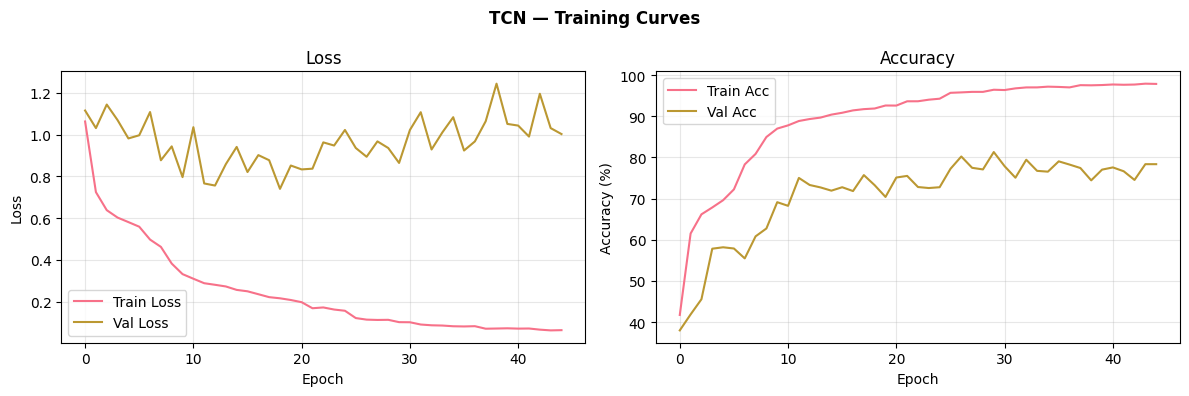

In [20]:
history = trainer_tcn.training_history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('TCN — Training Curves', fontweight='bold')

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'],   label='Val Acc')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/results/figures/tcn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

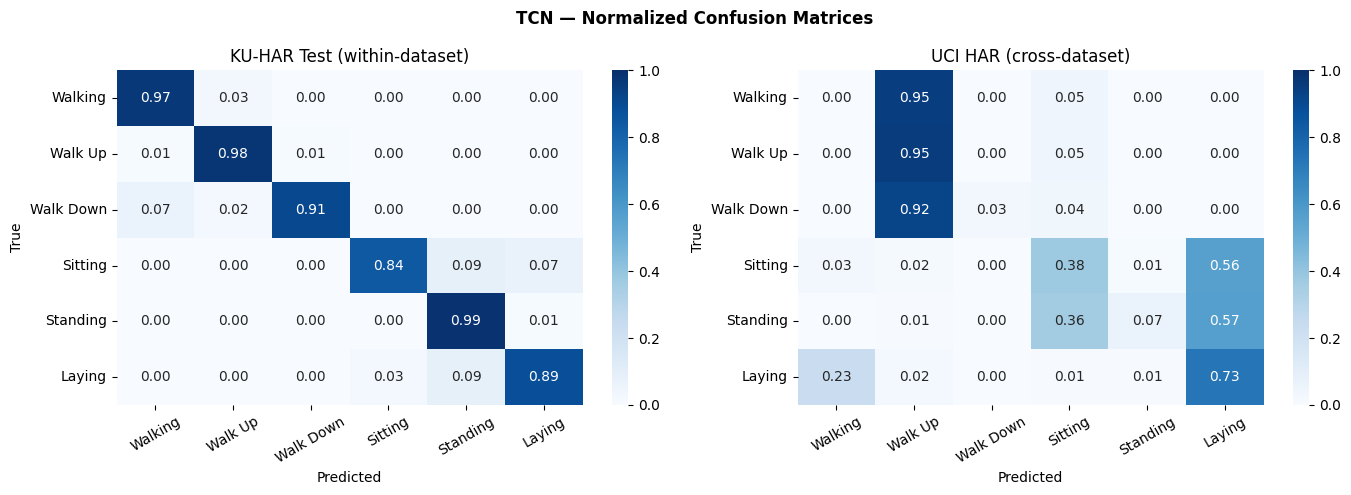

Per-class F1 (KU-HAR): ['0.975', '0.918', '0.940', '0.900', '0.919', '0.899']
Per-class F1 (UCI):    ['0.003', '0.496', '0.067', '0.400', '0.124', '0.524']


In [21]:
tcn_test_preds  = get_predictions(trainer_tcn, X_test,  y_test)
tcn_cross_preds = get_predictions(trainer_tcn, X_cross, y_cross)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TCN — Normalized Confusion Matrices', fontweight='bold')

for ax, (y_true, y_pred, title) in zip(axes, [
    (y_test,  tcn_test_preds,  'KU-HAR Test (within-dataset)'),
    (y_cross, tcn_cross_preds, 'UCI HAR (cross-dataset)'),
]):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names,
                vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('/content/results/figures/tcn_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

all_results['TCN']['test_preds']  = tcn_test_preds.tolist()
all_results['TCN']['cross_preds'] = tcn_cross_preds.tolist()
with open(src_dir / 'all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"Per-class F1 (KU-HAR): {[f'{v:.3f}' for v in all_results['TCN']['test']['f1_per_class']]}")
print(f"Per-class F1 (UCI):    {[f'{v:.3f}' for v in all_results['TCN']['cross']['f1_per_class']]}")

The TCN delivers the best within-dataset performance among deep learning models (Test F1: 0.925, Acc: 91.7%) with the fewest parameters (492K). Training is stable — val accuracy climbs from 38% at epoch 1 to a best of 81.3% at epoch 30 before early stopping at epoch 45, with train accuracy plateauing around 98% by epoch 20. Per-class F1 on KU-HAR is well-balanced across all six activities (0.899–0.975), with no single class failing. Cross-dataset transfer is however poor (UCI F1: 0.269, Acc: 36.8%). The failure is structured: Walking (0.003) and Walk Down (0.067) produce near-zero recall on UCI HAR, with only Walk Up (0.496) and Laying (0.524) partially surviving. The TCN's dilated causal convolutions overfit KU-HAR's device-specific temporal signatures despite the absence of recurrence. This is the direct motivation for TCN+DA — the backbone is expressive but requires explicit domain alignment to generalize.

### TCN+DA (Temporal Convolutional Network with Domain Adaptation)

This is our primary contribution. The TCN+DA shares the identical TCN encoder
(TemporalConvNet: 64 to 128 to 256 channels, kernel size 3, dilation 1 to 2 to4,
dropout p=0.3) with global average pooling, extended with a
Domain-Adversarial Neural Network (DANN) objective following Ganin et al.
(ICML 2015).

**Architecture:** The pooled 256-dim encoder output feeds two heads in
parallel:
- Activity classifier: Linear(256 to 256) to  ReLU to Dropout(0.5) to Linear(256→6),
  trained on labeled KU-HAR source samples only.
- Domain classifier: Linear(256 to 128) to ReLU to Dropout(0.5) to Linear(128 to 64)
  to ReLU to Dropout(0.5) to Linear(64→2), trained to distinguish KU-HAR
  (label 0) from UCI HAR (label 1).

A Gradient Reversal Layer (GRL) sits between the encoder and the domain
classifier. In the forward pass it is an identity; in the backward pass it
negates gradients by λ. This forces the shared encoder to simultaneously
maximize activity classification accuracy *and* minimize domain
discriminability — producing representations that are invariant to dataset
of origin.

**λ schedule:** Ganin sigmoid annealing λ(p) = (2/(1+exp(−10p)) − 1) × 1.0,
where p = epoch/MAX_EPOCHS. λ ramps from 0 at epoch 1 to ≈1.0 by epoch 60,
preventing the domain signal from overwhelming activity learning during early
training.

**Per-batch training:** Each source batch and a paired target batch (UCI HAR,
unlabeled, cycled from a separate DataLoader of 7,144 samples across 111
batches) are both forward-passed through the encoder. Only the source batch
contributes to activity loss; both batches contribute equally to domain loss
((source_domain_loss + target_domain_loss) / 2). The total loss is
activity_loss + domain_loss — there is no separate weighting coefficient
beyond what λ controls through the GRL.

**Optimizer:** Adam with three parameter groups — encoder at 0.5× base LR
(5e-4), activity classifier at base LR (1e-3), domain classifier at domain
LR (1e-3), all with weight decay 1e-4. ReduceLROnPlateau (factor=0.5,
patience=5) on val loss. A 50-epoch warmup disables early stopping so the
λ schedule can fully ramp before checkpoint selection begins; early stopping
(patience=15) activates from epoch 51 onward.

In [39]:
print("*" * 45)
print("Training TCN+DA (Domain Adaptation)")
print("*" * 45)

trainer_tcn_da = HARTrainer('TCN_DA', device=DEVICE)
trainer_tcn_da.setup_model()

tcn_da_val_metrics, tcn_da_test_metrics, tcn_da_cross_results = trainer_tcn_da.train(
    X_train, y_train, X_val, y_val,
    X_test=X_test, y_test=y_test,
    X_cross_test=X_cross, y_cross_test=y_cross,
    X_target_domain=X_target,
)

cross = tcn_da_cross_results.get('test', {})

all_results['TCN_DA'] = {
    'val':   tcn_da_val_metrics,
    'test':  tcn_da_test_metrics,
    'cross': cross,
}
with open(src_dir / 'all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"\nTCN+DA Results:")
print(f"  KU-HAR Val  Acc: {tcn_da_val_metrics.get('accuracy', 0):.4f}   F1: {tcn_da_val_metrics.get('f1_macro', 0):.4f}")
print(f"  KU-HAR Test Acc: {tcn_da_test_metrics.get('accuracy', 0):.4f}   F1: {tcn_da_test_metrics.get('f1_macro', 0):.4f}")
print(f"  UCI Cross   Acc: {cross.get('accuracy', 0):.4f}   F1: {cross.get('f1_macro', 0):.4f}")

*********************************************
Training TCN+DA (Domain Adaptation)
*********************************************
Setting up TCN_DA model...
Model: TCN_DA
Parameters: 533,384
Device: cuda
Training TCN_DA...
Preparing data loaders...
  Target domain loader: 7144 samples (111 batches)


Epoch 1: 100%|██████████| 211/211 [00:06<00:00, 33.90it/s, ActLoss=0.9434, DomLoss=0.3705, Acc=42.1%, DomAcc=78.9%]


Epoch 1/100:
  Train Loss: 1.0758, Train Acc: 42.08%
  Val Loss: 1.0653, Val Acc: 32.89%
  Domain Loss: 0.4524, Domain Acc: 78.85%
  Lambda: 0.0000
  Warmup epoch 1/50 (no early stopping yet)


Epoch 2: 100%|██████████| 211/211 [00:05<00:00, 36.39it/s, ActLoss=0.6823, DomLoss=0.5820, Acc=56.0%, DomAcc=67.8%]


Epoch 2/100:
  Train Loss: 0.7781, Train Acc: 55.98%
  Val Loss: 1.1609, Val Acc: 36.28%
  Domain Loss: 0.5527, Domain Acc: 67.75%
  Lambda: 0.0500
  Warmup epoch 2/50 (no early stopping yet)


...

Epoch 79/100:
  Train Loss: 0.1176, Train Acc: 95.65%
  Val Loss: 0.9639, Val Acc: 73.05%
  Domain Loss: 0.6873, Domain Acc: 55.43%
  Lambda: 0.9992
  No improvement for 13 epochs


Epoch 80: 100%|██████████| 211/211 [00:06<00:00, 35.05it/s, ActLoss=0.0665, DomLoss=0.6817, Acc=95.6%, DomAcc=55.0%]


Epoch 80/100:
  Train Loss: 0.1173, Train Acc: 95.62%
  Val Loss: 0.9593, Val Acc: 73.24%
  Domain Loss: 0.6881, Domain Acc: 54.97%
  Lambda: 0.9993
  No improvement for 14 epochs


Epoch 81: 100%|██████████| 211/211 [00:06<00:00, 33.91it/s, ActLoss=0.1186, DomLoss=0.6875, Acc=95.7%, DomAcc=55.2%]


Epoch 81/100:
  Train Loss: 0.1157, Train Acc: 95.70%
  Val Loss: 0.9609, Val Acc: 73.20%
  Domain Loss: 0.6875, Domain Acc: 55.18%
  Lambda: 0.9993
Early stopping triggered after 81 epochs

Final evaluation on validation set:
Validation Accuracy: 73.74%
Validation F1 (macro): 0.7766

Final evaluation on KU-HAR held-out test set:
Test Accuracy: 88.54%
Test F1 (macro): 0.9100

Cross-dataset evaluation (UCI HAR):
test Accuracy: 50.78%
test F1 (macro): 0.4871

TCN+DA Results:
  KU-HAR Val  Acc: 0.7374   F1: 0.7766
  KU-HAR Test Acc: 0.8854   F1: 0.9100
  UCI Cross   Acc: 0.5078   F1: 0.4871


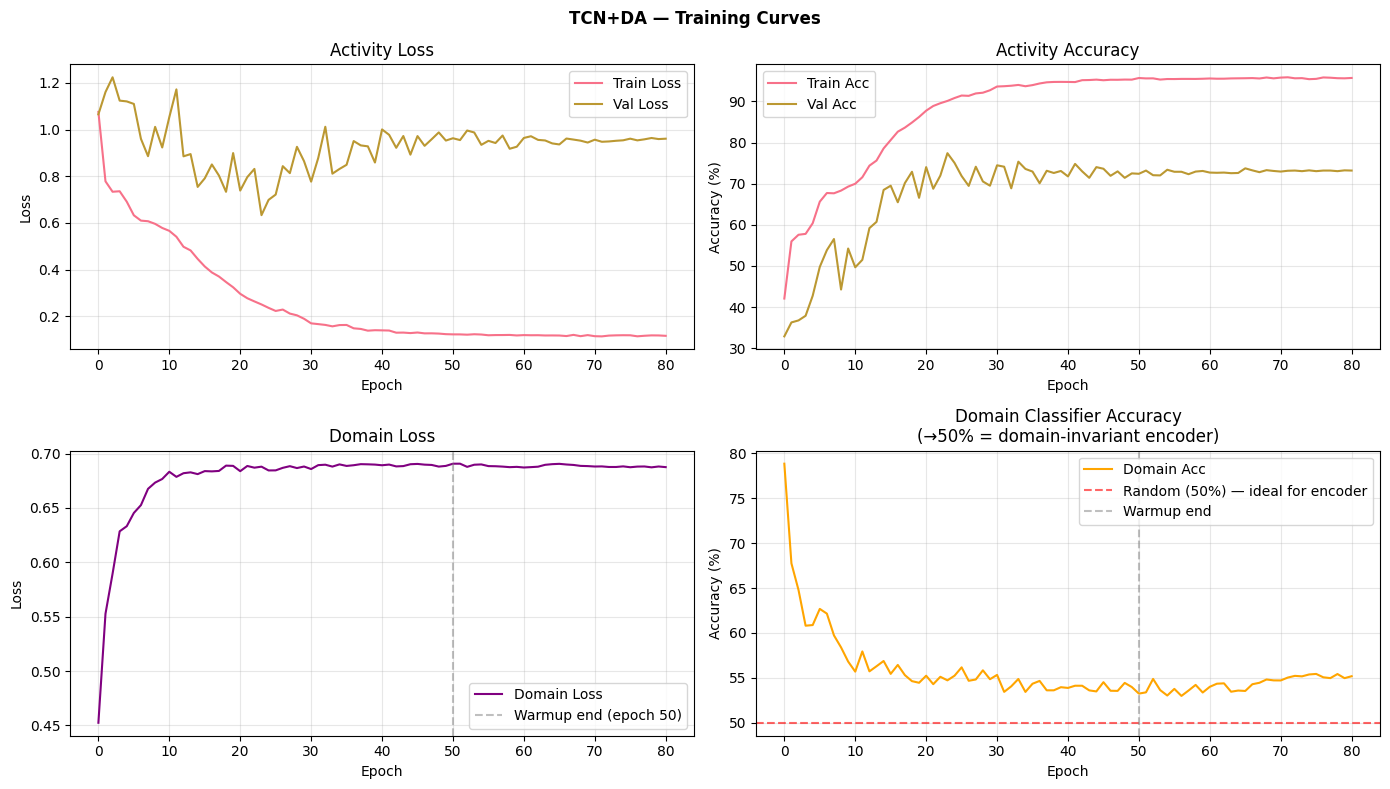

In [40]:
history = trainer_tcn_da.training_history

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('TCN+DA — Training Curves', fontweight='bold')

axes[0,0].plot(history['train_loss'], label='Train Loss')
axes[0,0].plot(history['val_loss'],   label='Val Loss')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
axes[0,0].set_title('Activity Loss'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(history['train_acc'], label='Train Acc')
axes[0,1].plot(history['val_acc'],   label='Val Acc')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Accuracy (%)')
axes[0,1].set_title('Activity Accuracy'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

if history.get('domain_loss'):
    axes[1,0].plot(history['domain_loss'], color='purple', label='Domain Loss')
    axes[1,0].axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='Warmup end (epoch 50)')
    axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Loss')
    axes[1,0].set_title('Domain Loss'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

    axes[1,1].plot(history['domain_acc'], color='orange', label='Domain Acc')
    axes[1,1].axhline(y=50, color='red', linestyle='--', alpha=0.6,
                      label='Random (50%) — ideal for encoder')
    axes[1,1].axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='Warmup end')
    axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Accuracy (%)')
    axes[1,1].set_title('Domain Classifier Accuracy\n(→50% = domain-invariant encoder)')
    axes[1,1].legend(); axes[1,1].grid(alpha=0.3)
else:
    axes[1,0].set_visible(False)
    axes[1,1].set_visible(False)

plt.tight_layout()
plt.savefig('/content/results/figures/tcn_da_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

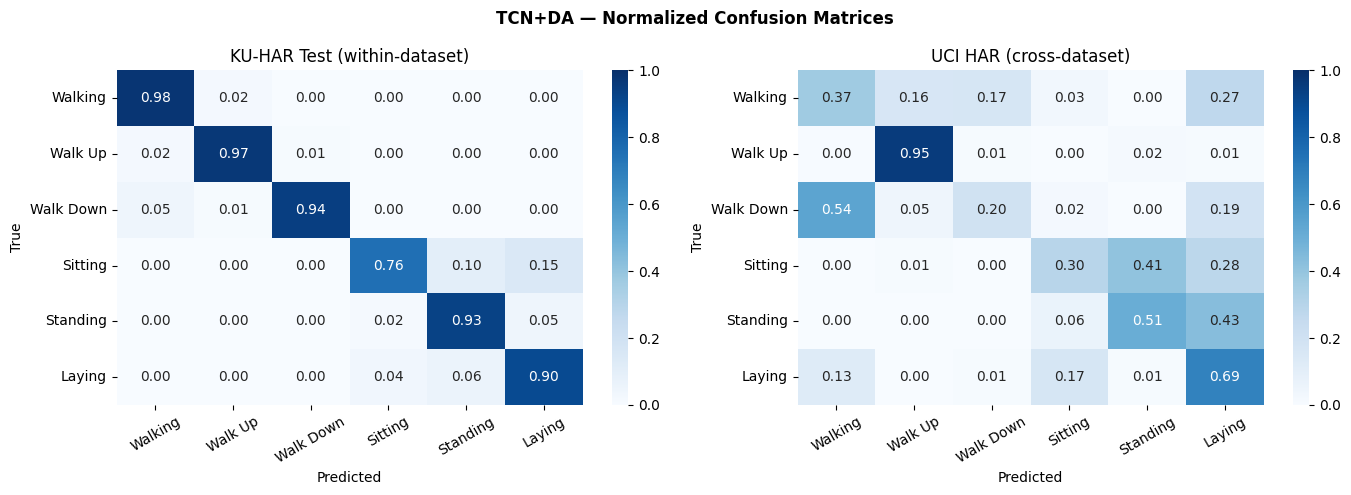

Per-class F1 (KU-HAR): ['0.982', '0.926', '0.965', '0.835', '0.898', '0.854']
Per-class F1 (UCI):    ['0.371', '0.873', '0.278', '0.371', '0.528', '0.501']


In [41]:
tcn_da_test_preds  = get_predictions(trainer_tcn_da, X_test,  y_test)
tcn_da_cross_preds = get_predictions(trainer_tcn_da, X_cross, y_cross)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TCN+DA — Normalized Confusion Matrices', fontweight='bold')

for ax, (y_true, y_pred, title) in zip(axes, [
    (y_test,  tcn_da_test_preds,  'KU-HAR Test (within-dataset)'),
    (y_cross, tcn_da_cross_preds, 'UCI HAR (cross-dataset)'),
]):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names,
                vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('/content/results/figures/tcn_da_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

all_results['TCN_DA']['test_preds']  = tcn_da_test_preds.tolist()
all_results['TCN_DA']['cross_preds'] = tcn_da_cross_preds.tolist()
with open(src_dir / 'all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"Per-class F1 (KU-HAR): {[f'{v:.3f}' for v in all_results['TCN_DA']['test']['f1_per_class']]}")
print(f"Per-class F1 (UCI):    {[f'{v:.3f}' for v in all_results['TCN_DA']['cross']['f1_per_class']]}")

TCN+DA achieves the best cross-dataset performance of all five models (UCI F1: 0.487, Acc: 50.8%), the only model to meaningfully clear random chance (16.7%) on UCI HAR. Within-dataset performance drops modestly relative to the vanilla TCN (Test F1: 0.910 vs. 0.925, Acc: 88.5% vs. 91.7%), reflecting the expected cost of regularizing the encoder toward domain-invariant features. The domain classifier accuracy converges to ~54–55% by epoch 50 — near the 50% target indicating domain confusion — confirming that the GRL successfully suppressed domain-discriminative features in the encoder.

Per-class cross-dataset F1 shows meaningful recovery across all six activities compared to the vanilla TCN: Walking improves from 0.003 to 0.371, Walk Up from 0.496 to 0.873 (the strongest transfer class), Sitting from 0.400 to 0.371, Standing from 0.124 to 0.528, and Laying from 0.524 to 0.501. Walk Down remains the hardest class (0.278), suggesting impact dynamics vary too greatly across devices for current domain alignment to resolve. Early stopping triggered at epoch 81 after the 50-epoch warmup, confirming the checkpoint reflects fully adapted features.


In [42]:
import pandas as pd

model_order = ['CNN', 'LSTM', 'CNN_LSTM', 'TCN', 'TCN_DA']
display_names = ['CNN', 'LSTM', 'CNN+LSTM', 'TCN', 'TCN+DA']

trainers = {
    'CNN':      trainer_cnn,
    'LSTM':     trainer_lstm,
    'CNN_LSTM': trainer_cnn_lstm,
    'TCN':      trainer_tcn,
    'TCN_DA':   trainer_tcn_da,
}

# Parameter counts
param_counts = {k: count_parameters(v.model) for k, v in trainers.items()}

rows = []
for key, display in zip(model_order, display_names):
    val_m   = all_results[key]['val']
    test_m  = all_results[key]['test']
    cross_m = all_results[key]['cross']
    rows.append({
        'Model':      display,
        'Params':     f"{param_counts[key]:,}",
        'Val Acc':    f"{val_m.get('accuracy',0):.4f}",
        'Val F1':     f"{val_m.get('f1_macro',0):.4f}",
        'Test Acc':   f"{test_m.get('accuracy',0):.4f}",
        'Test F1':    f"{test_m.get('f1_macro',0):.4f}",
        'Cross Acc':  f"{cross_m.get('accuracy',0):.4f}",
        'Cross F1':   f"{cross_m.get('f1_macro',0):.4f}",
    })

df = pd.DataFrame(rows).set_index('Model')
print("=" * 80)
print("FINAL RESULTS — All Deep Learning Models")
print("=" * 80)
print(df.to_string())
df.to_csv(src_dir / 'deep_learning_metrics.csv')
print(f"\n✓ Saved to {src_dir / 'deep_learning_metrics.csv'}")

FINAL RESULTS — All Deep Learning Models
             Params Val Acc  Val F1 Test Acc Test F1 Cross Acc Cross F1
Model                                                                  
CNN         611,046  0.8827  0.8969   0.9101  0.9219    0.4044   0.3003
LSTM        536,070  0.4806  0.5220   0.5350  0.5763    0.4013   0.2934
CNN+LSTM  1,073,894  0.5955  0.7311   0.5426  0.6819    0.4485   0.3506
TCN         492,102  0.8130  0.8646   0.9174  0.9252    0.3677   0.2688
TCN+DA      533,384  0.7374  0.7766   0.8854  0.9100    0.5078   0.4871

✓ Saved to /content/src/deep_learning_metrics.csv


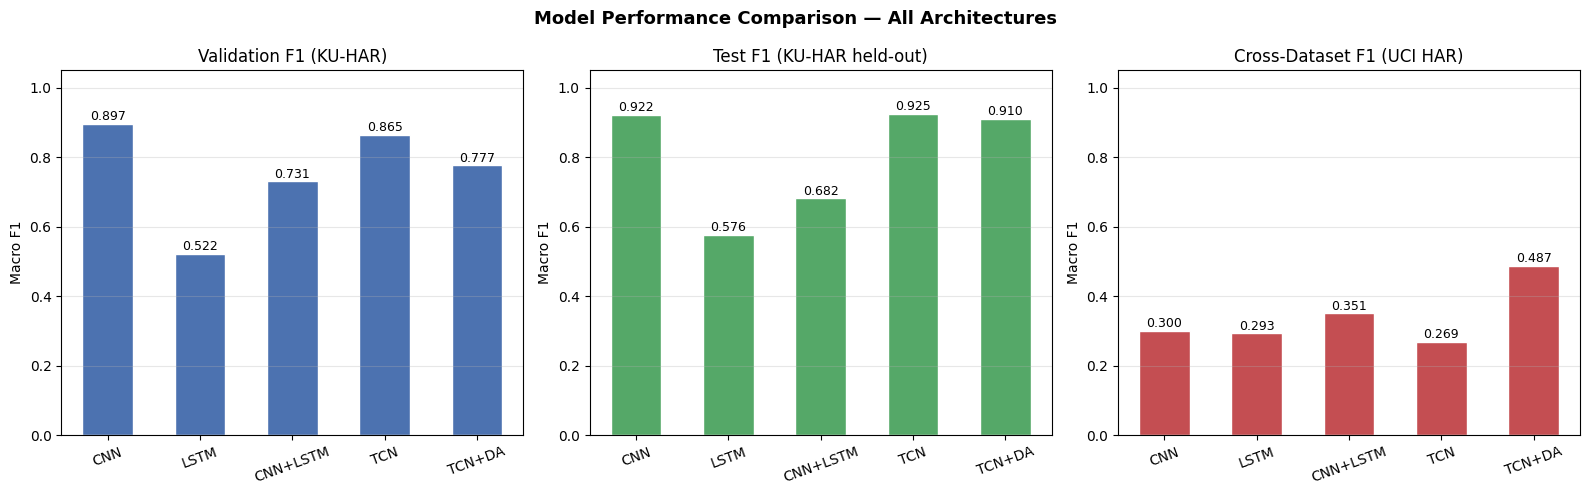

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Performance Comparison — All Architectures', fontweight='bold', fontsize=13)

colors_val   = '#4C72B0'
colors_test  = '#55A868'
colors_cross = '#C44E52'

val_f1s   = [all_results[k]['val'].get('f1_macro', 0)   for k in model_order]
test_f1s  = [all_results[k]['test'].get('f1_macro', 0)  for k in model_order]
cross_f1s = [all_results[k]['cross'].get('f1_macro', 0) for k in model_order]

x = np.arange(len(display_names))
w = 0.55

# Val F1
axes[0].bar(x, val_f1s, width=w, color=colors_val, edgecolor='white')
axes[0].set_title('Validation F1 (KU-HAR)')
axes[0].set_ylim(0, 1.05)
axes[0].set_xticks(x); axes[0].set_xticklabels(display_names, rotation=20)
axes[0].set_ylabel('Macro F1')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(val_f1s):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# Test F1
axes[1].bar(x, test_f1s, width=w, color=colors_test, edgecolor='white')
axes[1].set_title('Test F1 (KU-HAR held-out)')
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(x); axes[1].set_xticklabels(display_names, rotation=20)
axes[1].set_ylabel('Macro F1')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(test_f1s):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# Cross F1
axes[2].bar(x, cross_f1s, width=w, color=colors_cross, edgecolor='white')
axes[2].set_title('Cross-Dataset F1 (UCI HAR)')
axes[2].set_ylim(0, 1.05)
axes[2].set_xticks(x); axes[2].set_xticklabels(display_names, rotation=20)
axes[2].set_ylabel('Macro F1')
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(cross_f1s):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

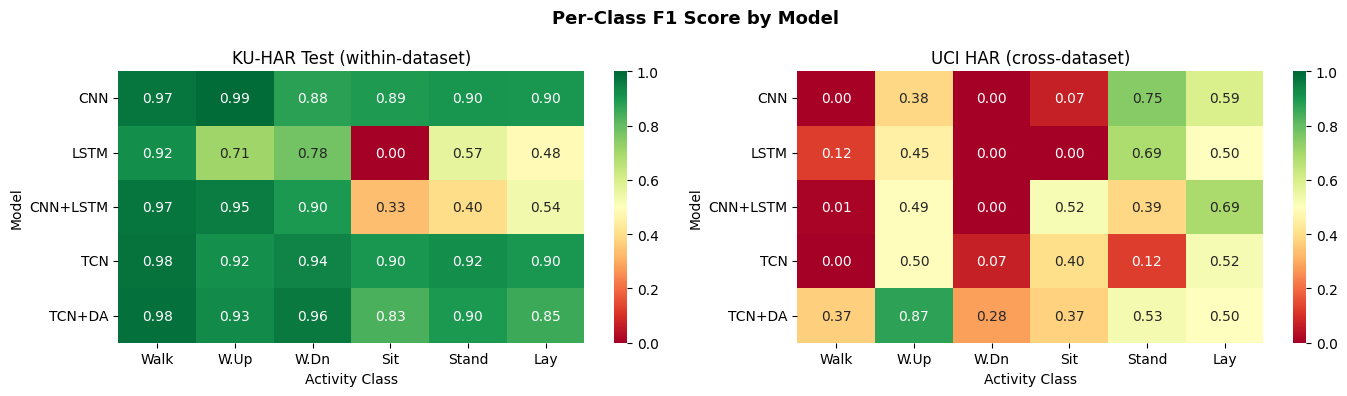

In [44]:
short_labels = ['Walk', 'W.Up', 'W.Dn', 'Sit', 'Stand', 'Lay']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Per-Class F1 Score by Model', fontweight='bold', fontsize=13)

for ax, split, title in zip(axes,
    ['test', 'cross'],
    ['KU-HAR Test (within-dataset)', 'UCI HAR (cross-dataset)']):

    matrix = np.array([
        all_results[k][split].get('f1_per_class', [0]*6)
        for k in model_order
    ])

    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='RdYlGn',
                ax=ax, vmin=0, vmax=1,
                xticklabels=short_labels,
                yticklabels=display_names)
    ax.set_title(title)
    ax.set_xlabel('Activity Class')
    ax.set_ylabel('Model')
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

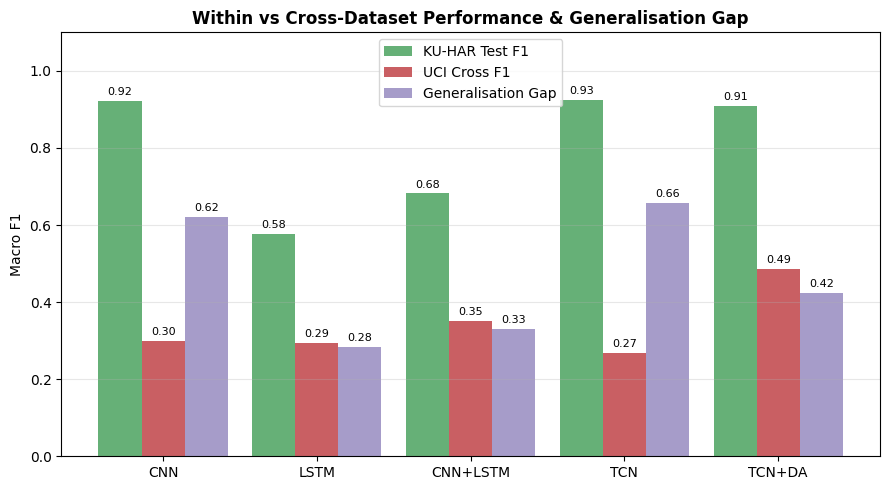

In [45]:
fig, ax = plt.subplots(figsize=(9, 5))

test_f1_arr  = np.array(test_f1s)
cross_f1_arr = np.array(cross_f1s)
gap          = test_f1_arr - cross_f1_arr

bar_w = 0.28
x = np.arange(len(display_names))

b1 = ax.bar(x - bar_w, test_f1_arr,  bar_w, label='KU-HAR Test F1',  color='#55A868', alpha=0.9)
b2 = ax.bar(x,          cross_f1_arr, bar_w, label='UCI Cross F1',    color='#C44E52', alpha=0.9)
b3 = ax.bar(x + bar_w,  gap,          bar_w, label='Generalisation Gap', color='#8172B2', alpha=0.7)

ax.set_xticks(x); ax.set_xticklabels(display_names)
ax.set_ylabel('Macro F1')
ax.set_title('Within vs Cross-Dataset Performance & Generalisation Gap', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 1.1)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'generalisation_gap.png', dpi=150, bbox_inches='tight')
plt.show()